## 🧠 ¿Qué es la Prueba t de Student?

La **prueba t de Student** es una prueba estadística utilizada para comparar medias y determinar si existe una diferencia estadísticamente significativa.

Se utiliza cuando:

- La muestra es pequeña (n < 30 o moderada)
- La varianza poblacional es desconocida
- Los datos siguen aproximadamente una distribución normal

---

## 🎯 Hipótesis

Para una muestra:

- H₀: μ = μ₀ (la media poblacional es igual a un valor específico)
- H₁: μ ≠ μ₀ (la media es diferente)

Para dos muestras independientes:

- H₀: μ₁ = μ₂
- H₁: μ₁ ≠ μ₂


# 📊 Prueba t de Student con el dataset Penguins
# 📌 1 - HIPOTESIS

En este notebook aplicaremos la prueba t de Student para comparar
la masa corporal promedio (body_mass_g) entre pingüinos machos y hembras.

Hipótesis:

H₀: μ_machos = μ_hembras  
H₁: μ_machos ≠ μ_hembras  

Nivel de significancia: α = 0.05

# 📌 2 – Cargar librerías y dataset

In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset("penguins")

# Ver primeras filas
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 📌 3 – tomamos muestras sesgadas

In [3]:
# Eliminar valores nulos en las variables que usaremos
df_clean = df[['body_mass_g', 'sex']].dropna()

In [4]:
df_clean

,body_mass_g,sex
0,3750.0,Male
1,3800.0,Female
2,3250.0,Female
4,3450.0,Female
5,3650.0,Male
...,...,...
338,4925.0,Female
340,4850.0,Female
341,5750.0,Male
342,5200.0,Female


In [5]:
# Separar grupos
machos = df_clean[df_clean['sex'] == 'Male']['body_mass_g']
hembras = df_clean[df_clean['sex'] == 'Female']['body_mass_g']

In [6]:
print("Cantidad machos:", len(machos))
print("Cantidad hembras:", len(hembras))

Cantidad machos: 168
Cantidad hembras: 165


# 📌 4 – Estadísticos descriptivos

In [7]:
print("Media machos:", np.mean(machos))
print("Media hembras:", np.mean(hembras))
print("Desv. estándar machos:", np.std(machos, ddof=1))
print("Desv. estándar hembras:", np.std(hembras, ddof=1))

Media machos: 4545.684523809524
Media hembras: 3862.2727272727275
Desv. estándar machos: 787.6288841581745
Desv. estándar hembras: 666.1720495161447


# 📌 5 – Visualización

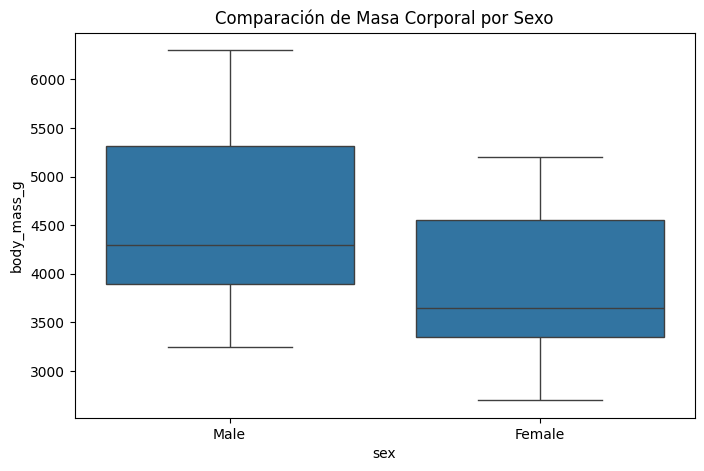

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sex', y='body_mass_g', data=df_clean)
plt.title("Comparación de Masa Corporal por Sexo")
plt.show()

# 📌 6 – Prueba t de Student

In [10]:
t_stat, p_value = stats.ttest_ind(machos,hembras)

print("Estadístico t:", t_stat)
print("Valor p:", p_value)

Estadístico t: 8.541720337994516
Valor p: 4.897246751596224e-16


## 🔎 Interpretación

Regla de decisión:

- Si p < 0.05 → Rechazamos H₀
- Si p ≥ 0.05 → No rechazamos H₀

Si el valor p es menor a 0.05, concluimos que existe una diferencia
estadísticamente significativa en la masa corporal promedio
entre pingüinos machos y hembras.

En el dataset penguins normalmente se obtiene:

✔ Machos pesan significativamente más que hembras.